# 🚀 Mini Projects — Applying Python End-to-End

Small, self-contained projects that combine ideas from the earlier notebooks
(`01_basics` → `12_matplotlib`) into something real. Each project is intentionally short but
complete: problem statement, implementation with comments, and a quick demo run.

## Table of Contents
1. [To-Do List Manager](#1) — OOP, file I/O, JSON persistence
2. [Word Frequency Counter](#2) — strings, dicts, file handling
3. [Simple Calculator (REPL-style)](#3) — functions, exceptions, control flow
4. [Contact Book (CSV-backed)](#4) — OOP, CSV, CRUD operations
5. [Data Analysis Mini-Project](#5) — NumPy + Pandas + Matplotlib together
6. [Simple Password Strength Checker](#6) — strings, regex, control flow


<a id="1"></a>
# 1. To-Do List Manager
A class-based task manager that persists tasks to a JSON file, so your list survives between
runs. Demonstrates: **OOP, file handling, JSON, list comprehensions, datetime**.


In [1]:
import json
import os
from datetime import datetime

class TodoList:
    """A simple to-do list that persists itself to a JSON file."""

    def __init__(self, filepath="todos.json"):
        self.filepath = filepath
        self.tasks = self._load()

    def _load(self):
        # load existing tasks from disk, or start with an empty list if none exist
        if os.path.exists(self.filepath):
            with open(self.filepath, "r") as f:
                return json.load(f)
        return []

    def _save(self):
        with open(self.filepath, "w") as f:
            json.dump(self.tasks, f, indent=2)

    def add(self, description, priority="medium"):
        task = {
            "id": len(self.tasks) + 1,
            "description": description,
            "priority": priority,
            "done": False,
            "created": datetime.now().strftime("%Y-%m-%d %H:%M"),
        }
        self.tasks.append(task)
        self._save()
        return task

    def complete(self, task_id):
        for task in self.tasks:
            if task["id"] == task_id:
                task["done"] = True
                self._save()
                return True
        return False   # task not found

    def pending(self):
        # list comprehension - one of the "advanced Python" concepts, applied here
        return [t for t in self.tasks if not t["done"]]

    def summary(self):
        done_count = sum(1 for t in self.tasks if t["done"])
        return f"{done_count}/{len(self.tasks)} tasks completed"

    def __str__(self):
        lines = []
        for t in self.tasks:
            status = "x" if t["done"] else " "
            lines.append(f"[{status}] #{t['id']} ({t['priority']}) {t['description']}")
        return "\n".join(lines) if lines else "No tasks yet."


# --- Demo ---
todo = TodoList("demo_todos.json")
todo.add("Learn Python advanced topics", priority="high")
todo.add("Write NumPy notebook", priority="high")
todo.add("Buy groceries", priority="low")
todo.complete(1)

print(todo)
print()
print(todo.summary())
print("Pending:", [t["description"] for t in todo.pending()])

os.remove("demo_todos.json")   # cleanup demo file

[x] #1 (high) Learn Python advanced topics
[ ] #2 (high) Write NumPy notebook
[ ] #3 (low) Buy groceries

1/3 tasks completed
Pending: ['Write NumPy notebook', 'Buy groceries']


<a id="2"></a>
# 2. Word Frequency Counter
Reads text and reports the most common words. Demonstrates: **string processing, dicts,
`collections.Counter`, sorting**.

In [2]:
import re
from collections import Counter

def word_frequencies(text, top_n=5):
    """Return the top_n most common words in `text` (case-insensitive, punctuation stripped)."""
    # \w+ matches sequences of "word" characters (letters/digits/underscore)
    words = re.findall(r"\w+", text.lower())
    counts = Counter(words)
    return counts.most_common(top_n)

sample_text = """
Python is a great language. Python is easy to learn, and Python is powerful.
Many developers love Python because Python code is readable.
"""

for word, count in word_frequencies(sample_text, top_n=5):
    print(f"{word:<10} {count}")

python     5
is         4
a          1
great      1
language   1


<a id="3"></a>
# 3. Simple Calculator (REPL-style)
A calculator function that safely evaluates basic arithmetic expressions. Demonstrates:
**functions, exception handling, control flow** (no `eval()` — building it "by hand" for
safety and to show the underlying logic).


In [3]:
def calculate(expression):
    """
    Evaluate a simple two-operand expression like "3 + 4" or "10 / 2".
    Supports + - * / and raises clear errors for bad input.
    """
    tokens = expression.split()
    if len(tokens) != 3:
        raise ValueError("Expression must be in the form: <number> <operator> <number>")

    left_str, operator, right_str = tokens

    try:
        left = float(left_str)
        right = float(right_str)
    except ValueError:
        raise ValueError(f"'{left_str}' and '{right_str}' must both be numbers")

    operations = {
        "+": lambda a, b: a + b,
        "-": lambda a, b: a - b,
        "*": lambda a, b: a * b,
        "/": lambda a, b: a / b if b != 0 else (_ for _ in ()).throw(ZeroDivisionError("division by zero")),
    }

    if operator not in operations:
        raise ValueError(f"Unsupported operator '{operator}'. Use one of: {list(operations.keys())}")

    return operations[operator](left, right)


# --- Demo: run a batch of expressions, handling errors gracefully ---
test_expressions = ["3 + 4", "10 / 2", "7 * 6", "5 / 0", "abc + 2", "1 2 3"]

for expr in test_expressions:
    try:
        result = calculate(expr)
        print(f"{expr:<12} = {result}")
    except (ValueError, ZeroDivisionError) as e:
        print(f"{expr:<12} -> Error: {e}")


3 + 4        = 7.0
10 / 2       = 5.0
7 * 6        = 42.0
5 / 0        -> Error: division by zero
abc + 2      -> Error: 'abc' and '2' must both be numbers
1 2 3        -> Error: Unsupported operator '2'. Use one of: ['+', '-', '*', '/']


<a id="4"></a>
# 4. Contact Book (CSV-backed)
A small CRUD (Create, Read, Update, Delete) app for contacts, backed by a CSV file.
Demonstrates: **OOP, CSV file handling, list/dict manipulation**.


In [4]:
import csv
import os

class ContactBook:
    def __init__(self, filepath="contacts.csv"):
        self.filepath = filepath
        self.fieldnames = ["name", "phone", "email"]
        if not os.path.exists(self.filepath):
            self._write_all([])   # start with an empty CSV (just the header)

    def _read_all(self):
        with open(self.filepath, "r", newline="") as f:
            return list(csv.DictReader(f))

    def _write_all(self, contacts):
        with open(self.filepath, "w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=self.fieldnames)
            writer.writeheader()
            writer.writerows(contacts)

    def add(self, name, phone, email):
        contacts = self._read_all()
        contacts.append({"name": name, "phone": phone, "email": email})
        self._write_all(contacts)

    def find(self, name):
        return [c for c in self._read_all() if name.lower() in c["name"].lower()]

    def update(self, name, **updates):
        contacts = self._read_all()
        updated = False
        for c in contacts:
            if c["name"].lower() == name.lower():
                c.update(updates)
                updated = True
        self._write_all(contacts)
        return updated

    def delete(self, name):
        contacts = self._read_all()
        remaining = [c for c in contacts if c["name"].lower() != name.lower()]
        deleted = len(remaining) != len(contacts)
        self._write_all(remaining)
        return deleted

    def all(self):
        return self._read_all()


# --- Demo ---
book = ContactBook("demo_contacts.csv")
book.add("Alice Smith", "555-1234", "alice@example.com")
book.add("Bob Jones", "555-5678", "bob@example.com")

print("All contacts:", book.all())
print("Search 'alice':", book.find("alice"))

book.update("Bob Jones", phone="555-0000")
print("After update:", book.find("bob"))

book.delete("Alice Smith")
print("After delete:", book.all())

os.remove("demo_contacts.csv")   # cleanup demo file

All contacts: [{'name': 'Alice Smith', 'phone': '555-1234', 'email': 'alice@example.com'}, {'name': 'Bob Jones', 'phone': '555-5678', 'email': 'bob@example.com'}]
Search 'alice': [{'name': 'Alice Smith', 'phone': '555-1234', 'email': 'alice@example.com'}]
After update: [{'name': 'Bob Jones', 'phone': '555-0000', 'email': 'bob@example.com'}]
After delete: [{'name': 'Bob Jones', 'phone': '555-0000', 'email': 'bob@example.com'}]


<a id="5"></a>
# 5. Data Analysis Mini-Project
Ties **NumPy + Pandas + Matplotlib** together: generate synthetic sales data, analyze it, and
visualize the result — a realistic mini version of a real data analysis workflow.

        date   sales region
0 2024-01-01  100.01  South
1 2024-01-02  119.75  South
2 2024-01-03  119.00  North
3 2024-01-04  103.14   West
4 2024-01-05   91.27  South
                      date       sales
count                   90   90.000000
mean   2024-02-14 12:00:00  148.555667
min    2024-01-01 00:00:00   76.200000
25%    2024-01-23 06:00:00  123.252500
50%    2024-02-14 12:00:00  146.795000
75%    2024-03-07 18:00:00  177.647500
max    2024-03-30 00:00:00  223.500000
std                    NaN   34.868587
            sum    mean  count
region                        
East    3301.34  157.21     21
North   2522.87  140.16     18
South   4351.42  150.05     29
West    3194.38  145.20     22
week
1    701.08
2    781.15
3    772.01
4    845.58
5    917.12
Name: sales, dtype: float64


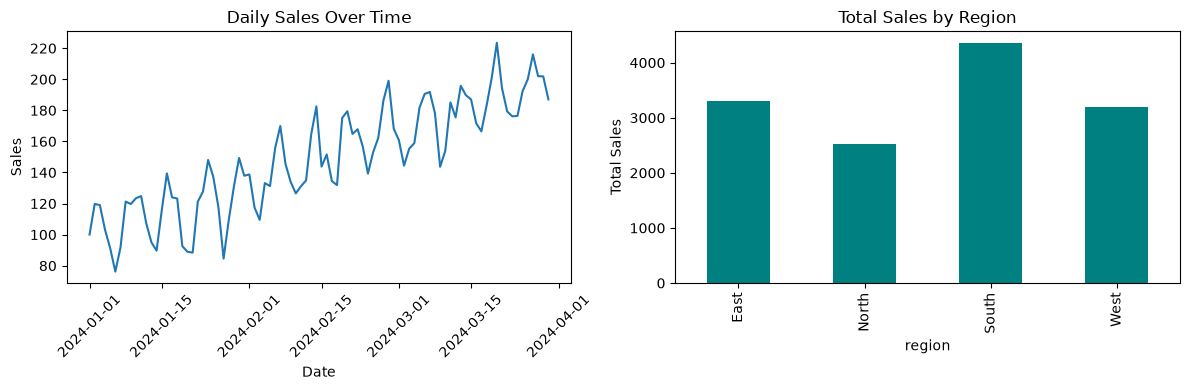

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Generate synthetic data (NumPy) ---
rng = np.random.default_rng(seed=7)
n_days = 90
dates = pd.date_range("2024-01-01", periods=n_days, freq="D")

# simulate a trend + weekly seasonality + noise
trend = np.linspace(100, 200, n_days)
weekly_pattern = 20 * np.sin(np.arange(n_days) * (2 * np.pi / 7))
noise = rng.normal(0, 10, n_days)
sales = trend + weekly_pattern + noise
sales = np.clip(sales, 0, None)   # sales can't be negative

regions = rng.choice(["East", "West", "North", "South"], size=n_days)

# --- 2. Build a DataFrame (Pandas) ---
df = pd.DataFrame({"date": dates, "sales": sales.round(2), "region": regions})
print(df.head())
print(df.describe())

# --- 3. Analyze (Pandas) ---
by_region = df.groupby("region")["sales"].agg(["sum", "mean", "count"]).round(2)
print(by_region)

df["week"] = df["date"].dt.isocalendar().week
weekly_totals = df.groupby("week")["sales"].sum()
print(weekly_totals.head())

# --- 4. Visualize (Matplotlib) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df["date"], df["sales"])
axes[0].set_title("Daily Sales Over Time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Sales")
axes[0].tick_params(axis="x", rotation=45)

by_region["sum"].plot(kind="bar", ax=axes[1], color="teal")
axes[1].set_title("Total Sales by Region")
axes[1].set_ylabel("Total Sales")

plt.tight_layout()
plt.show()


<a id="6"></a>
# 6. Simple Password Strength Checker
Checks a password against common strength rules and gives feedback. Demonstrates: **regex,
string methods, control flow**.


In [6]:
import re

def check_password_strength(password):
    """Return (score 0-5, list of feedback messages) for a given password."""
    score = 0
    feedback = []

    checks = [
        (len(password) >= 8, "Use at least 8 characters"),
        (re.search(r"[A-Z]", password) is not None, "Add an uppercase letter"),
        (re.search(r"[a-z]", password) is not None, "Add a lowercase letter"),
        (re.search(r"\d", password) is not None, "Add a digit"),
        (re.search(r"[!@#$%^&*(),.?\":{}|<>]", password) is not None, "Add a special character"),
    ]

    for passed, message in checks:
        if passed:
            score += 1
        else:
            feedback.append(message)

    strength_labels = {0: "Very Weak", 1: "Weak", 2: "Weak", 3: "Moderate", 4: "Strong", 5: "Very Strong"}
    return score, strength_labels[score], feedback


# --- Demo ---
test_passwords = ["password", "Password1", "P@ssw0rd!", "abc", "Str0ng&Secure123"]

for pwd in test_passwords:
    score, label, feedback = check_password_strength(pwd)
    print(f"'{pwd}' -> {label} ({score}/5)")
    if feedback:
        print("   Suggestions:", "; ".join(feedback))


'password' -> Weak (2/5)
   Suggestions: Add an uppercase letter; Add a digit; Add a special character
'Password1' -> Strong (4/5)
   Suggestions: Add a special character
'P@ssw0rd!' -> Very Strong (5/5)
'abc' -> Weak (1/5)
   Suggestions: Use at least 8 characters; Add an uppercase letter; Add a digit; Add a special character
'Str0ng&Secure123' -> Very Strong (5/5)


## Ideas for further projects
- CLI weather app (using the `requests` library + a public API)
- A simple REST API with `Flask`/`FastAPI`
- A Tic-Tac-Toe or Hangman game (OOP + control flow)
- Web scraper with `requests` + `BeautifulSoup`
- A basic Markdown-to-HTML converter (string/regex processing)
- Expand the data analysis project with `scikit-learn` for a simple prediction model

**This wraps up the `01_basics` → `13_projects` learning path. Happy building! 🎉**